# Loading + Partitioning Dataset

**Dataset:** https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset

In [ ]:
import kagglehub

# Download latest version
dir_path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")

print("Path to dataset files:", dir_path)

Using Colab cache for faster access to the 'sleep-health-and-daily-performance-dataset' dataset.
Path to dataset files: /kaggle/input/sleep-health-and-daily-performance-dataset


In [ ]:
!pip install mlflow --quiet

## MLflow Setup

In [ ]:
import mlflow
import warnings
import os
from sklearn.metrics import classification_report

# Suppress UserWarning about feature names from LightGBM for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Reverting to filesystem tracking
tracking_path = "./mlruns"
mlflow.set_tracking_uri(f"file://{os.path.abspath(tracking_path)}")

# Ensure directory and .trash exist to avoid errors
os.makedirs(os.path.join(tracking_path, ".trash"), exist_ok=True)

# Set the experiment name
mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

def log_classification_report_metrics(y_true, y_pred, prefix=""):
    """Logs classification report metrics to MLflow."""
    report = classification_report(y_true, y_pred, output_dict=True)
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            for metric_name, value in metrics.items():
                mlflow.log_metric(f"{prefix}{label}_{metric_name}", value)
        else:
            mlflow.log_metric(f"{prefix}{label}", metrics)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
import os

# List files to find the exact CSV name if needed
print(os.listdir(dir_path))

['sleep_health_dataset.csv']


## Creating the Train and Test Datasets

In [ ]:
# main dataset
df = pd.read_csv(f"{dir_path}/sleep_health_dataset.csv")

# removing unneeded features
df = df.drop(columns = ['cognitive_performance_score', 'felt_rested'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

**OBJECTIVE:** to predict 'sleep_disorder_risk'

In [ ]:
# train and test datasets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=67)

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

Train shape: (80000, 30)
Test shape: (20000, 30)


In [ ]:
# creating the test set
X_test = test_df.drop(columns=['sleep_disorder_risk'])
y_test = test_df['sleep_disorder_risk']

# Data Inspection

In [ ]:
train_df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,50031.935400,34.735087,26.288246,6.423717,4.867788,20.238899,20.252416,19.828325,3.349900,38.790500,...,0.451937,7501.725438,14.951300,5.735883,7.138459,66.586637,0.561575,0.084875,20.535050,1.200879
std,28866.912431,11.049267,4.478915,1.273142,1.509262,3.405022,4.261176,7.590637,1.923445,69.355189,...,0.497688,3460.484790,21.411781,1.619359,3.484352,7.233989,0.496197,0.278697,2.899468,0.787147
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,500.000000,0.000000,1.000000,0.000000,45.000000,0.000000,0.000000,15.000000,-1.000000
25%,25035.500000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,5048.000000,0.000000,4.800000,4.700000,62.000000,0.000000,0.000000,18.500000,0.670000
50%,50078.000000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,7444.000000,0.000000,5.800000,7.400000,67.000000,1.000000,0.000000,20.500000,1.200000
75%,75059.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,1.000000,9898.000000,30.000000,6.800000,9.700000,71.000000,1.000000,0.000000,22.500000,1.740000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,55.000000,8.000000,400.000000,...,1.000000,20000.000000,116.000000,10.000000,18.000000,99.000000,1.000000,1.000000,28.000000,3.000000


## Histograms + Countplots

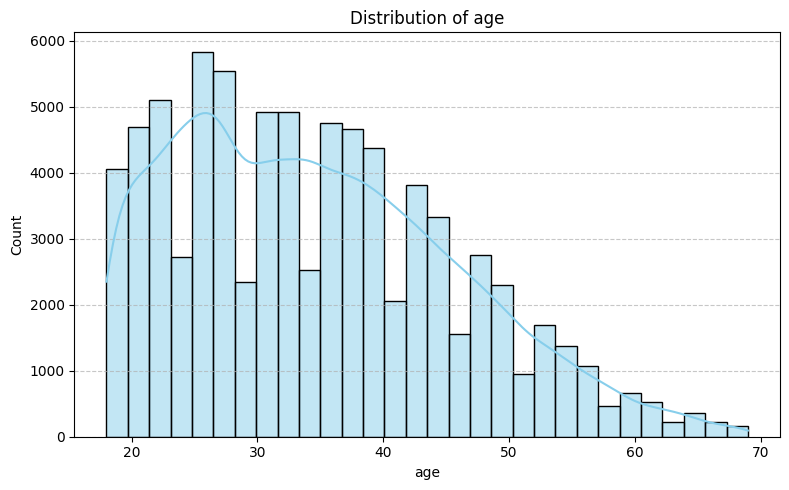

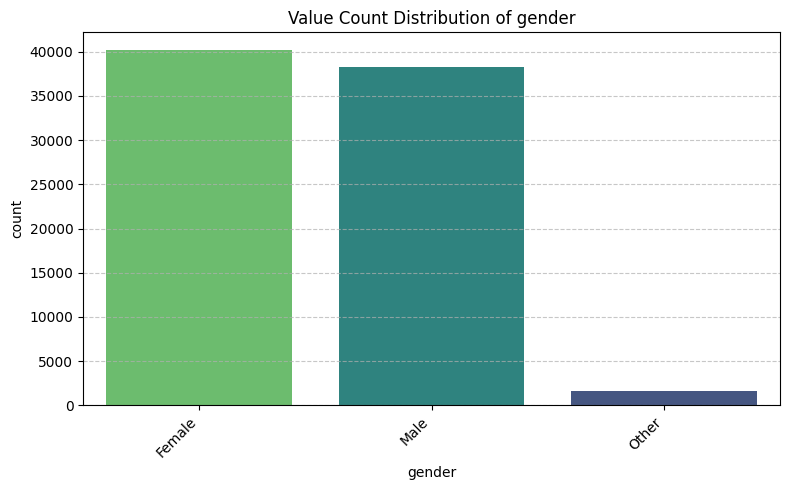

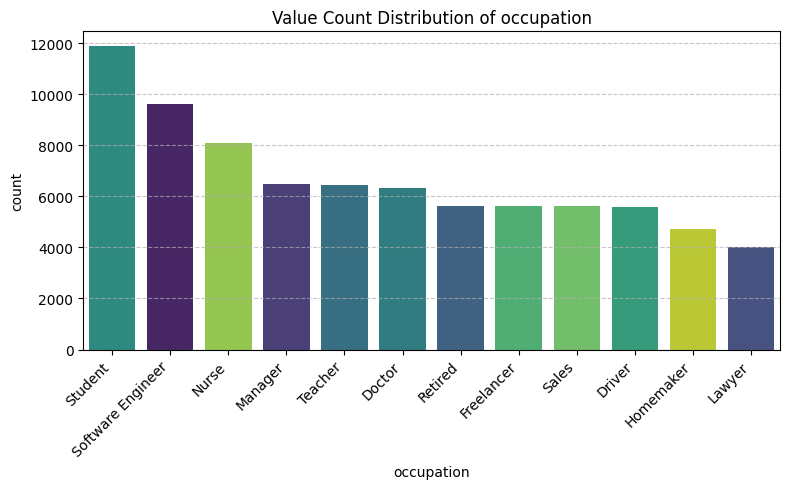

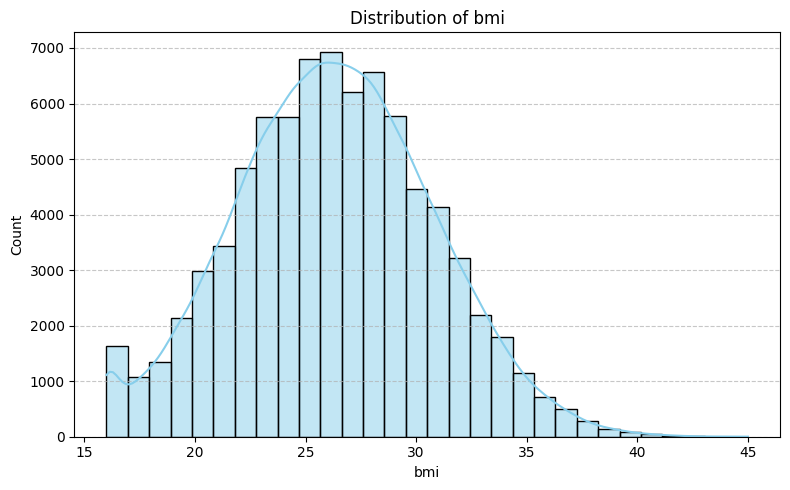

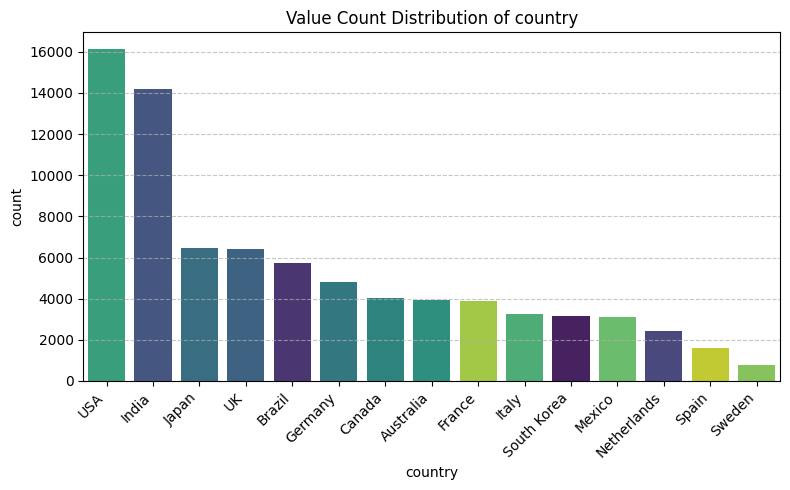

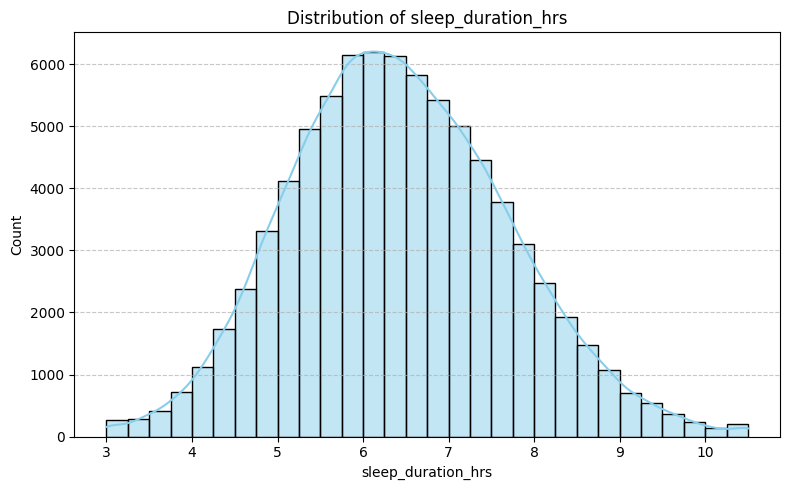

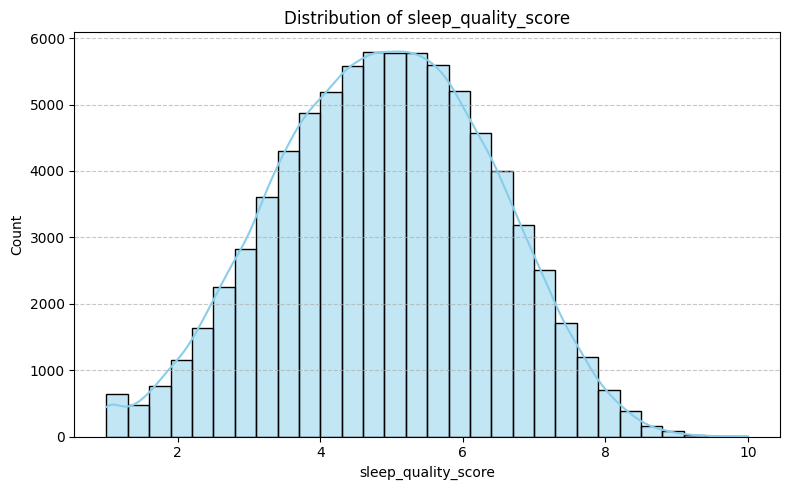

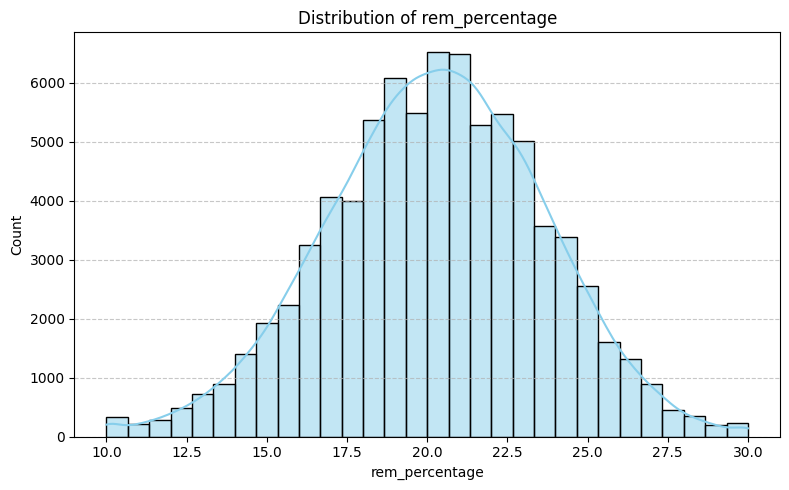

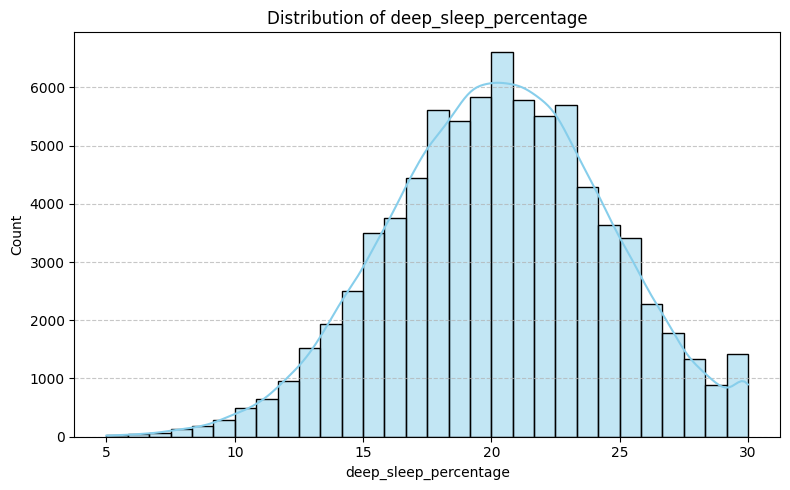

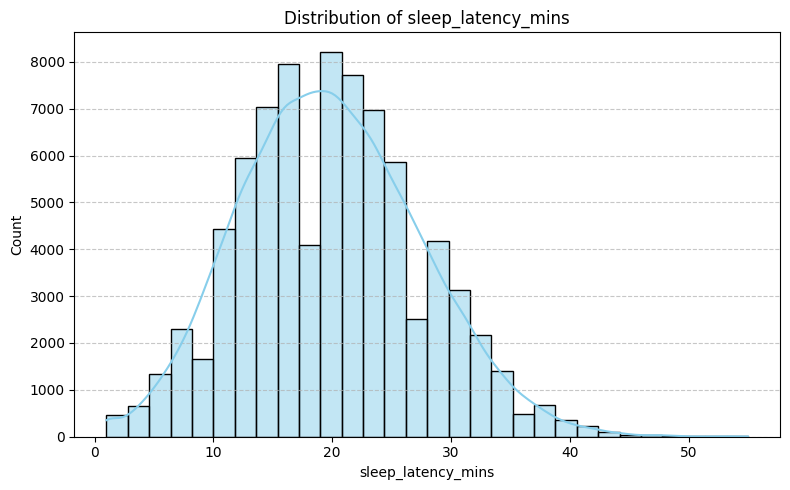

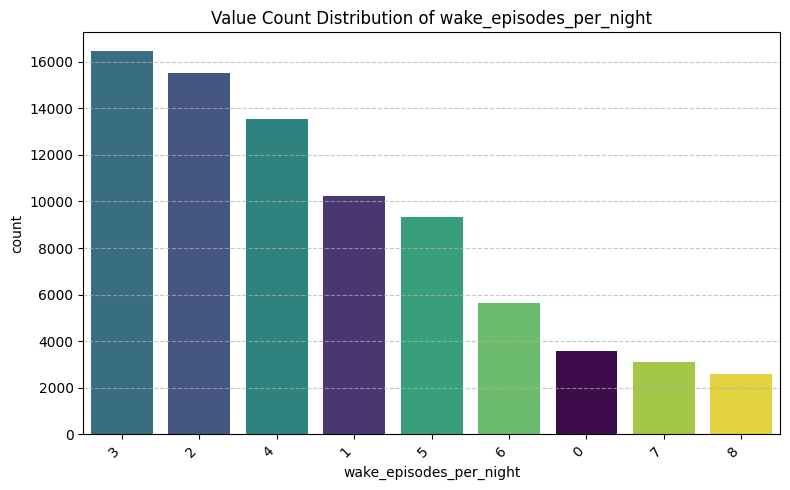

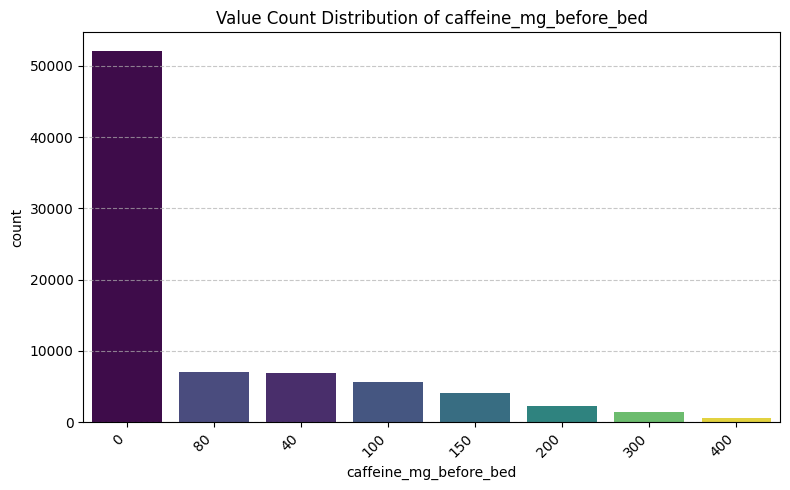

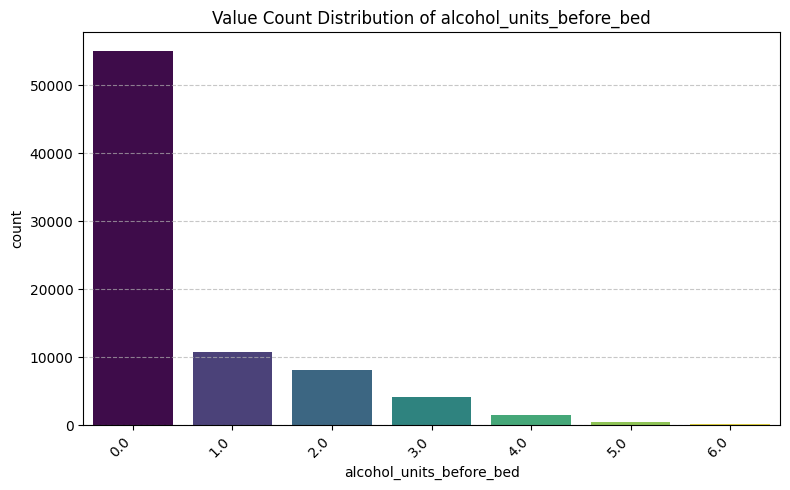

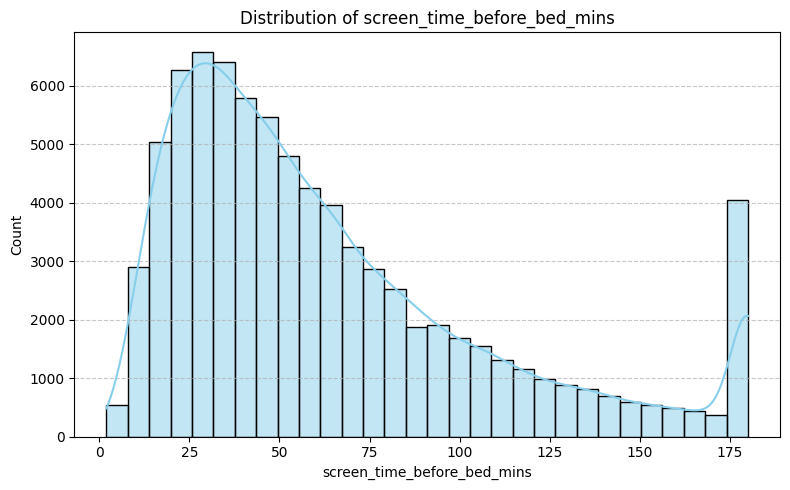

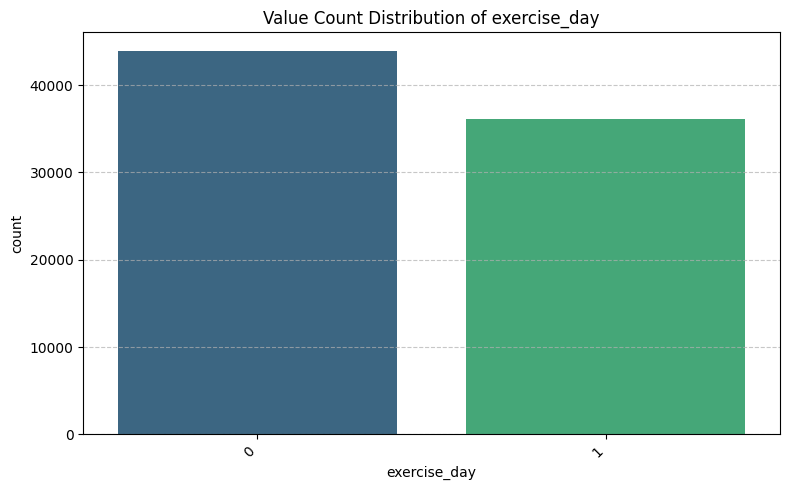

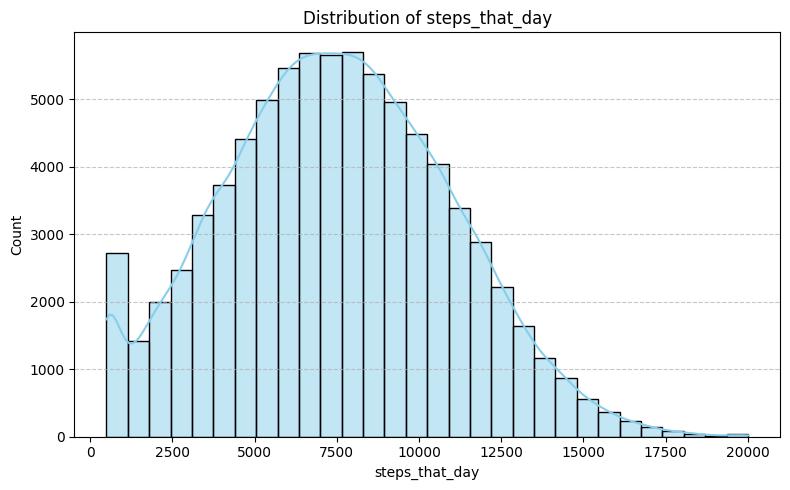

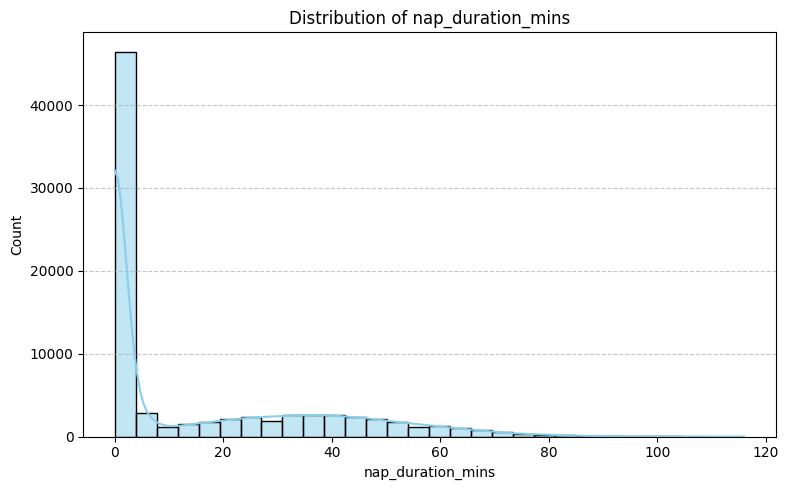

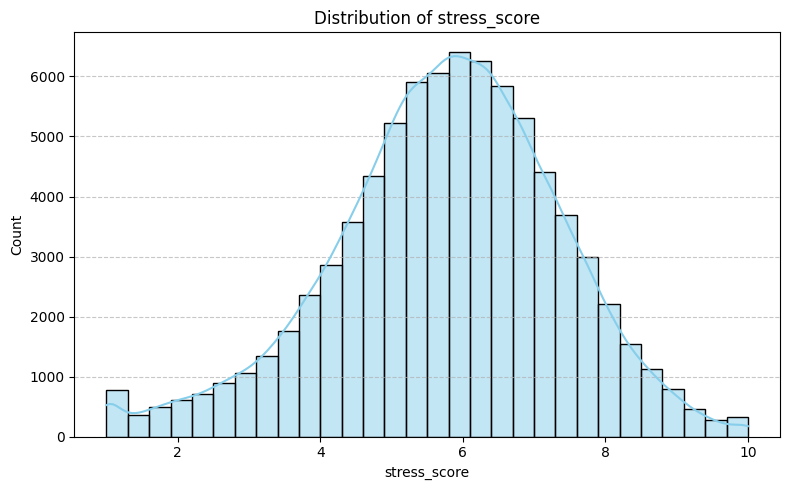

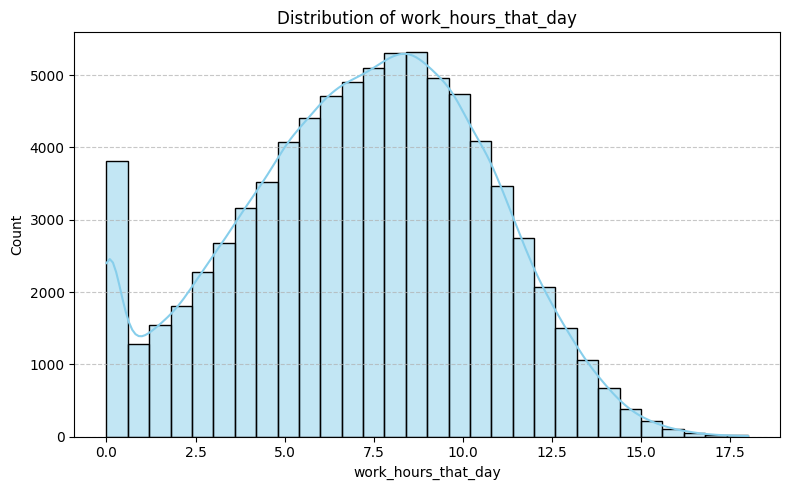

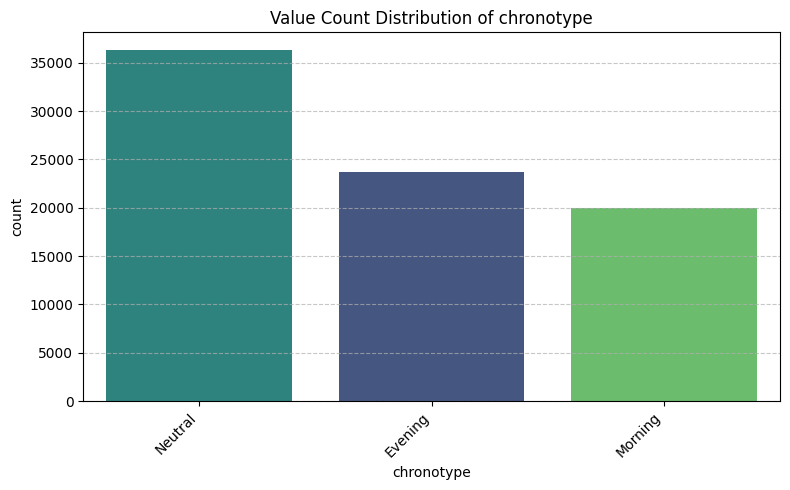

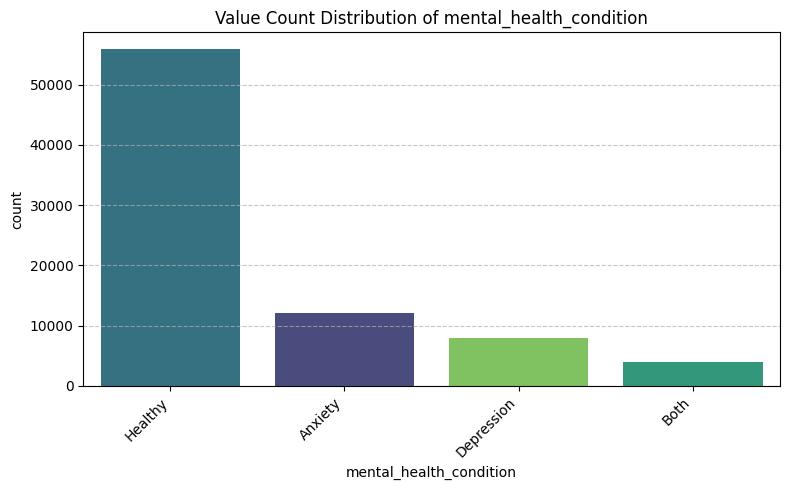

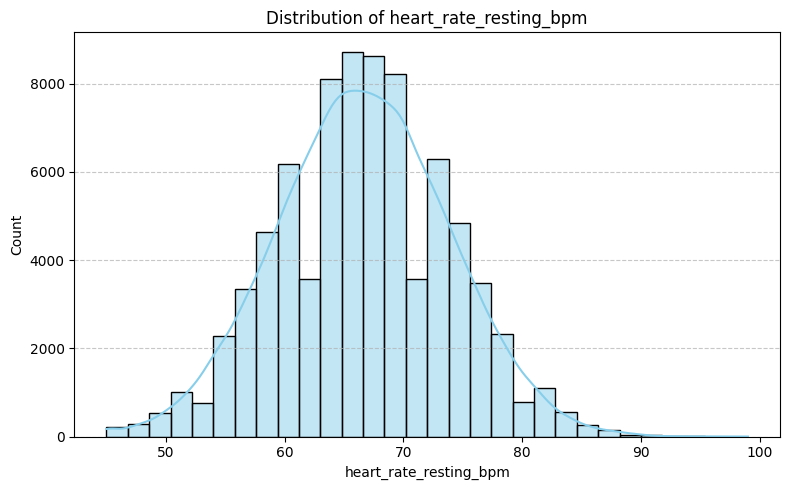

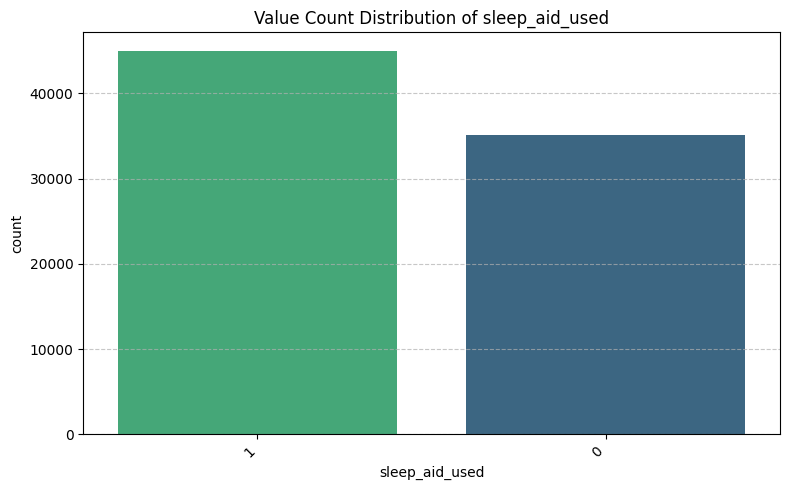

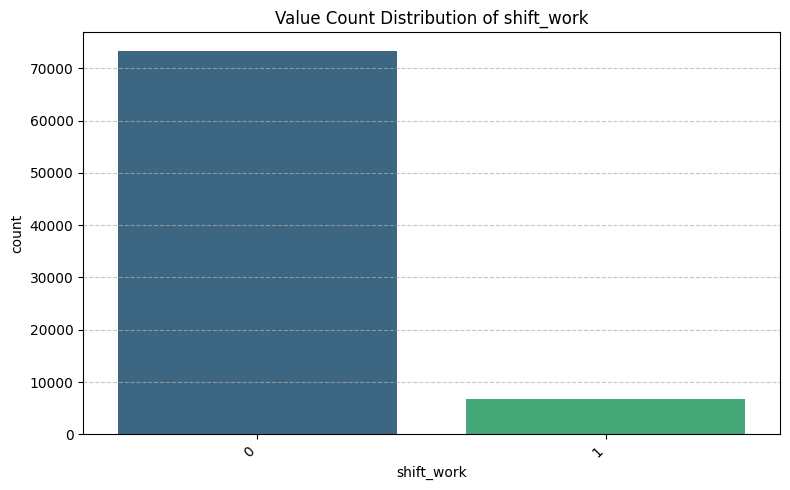

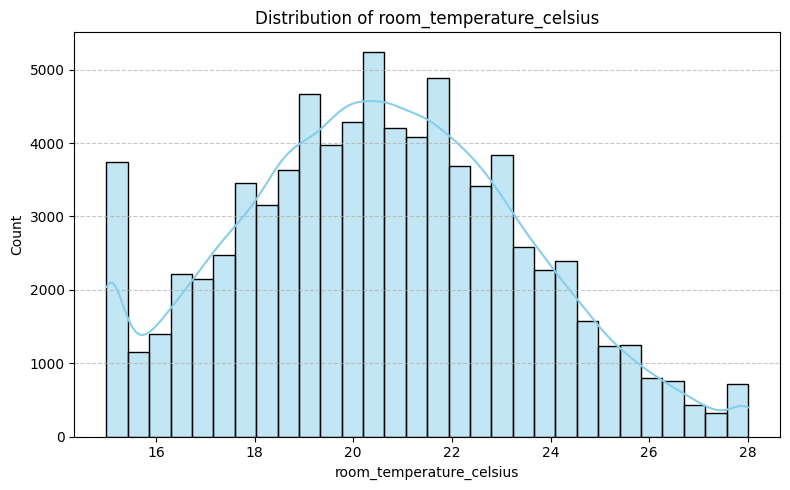

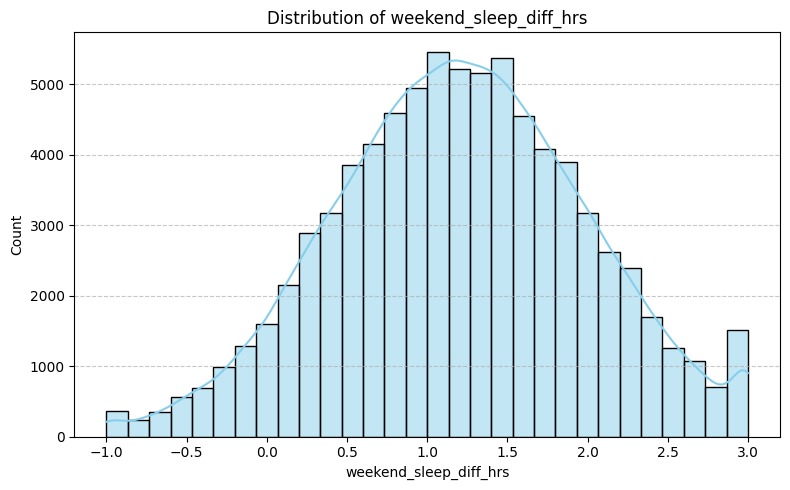

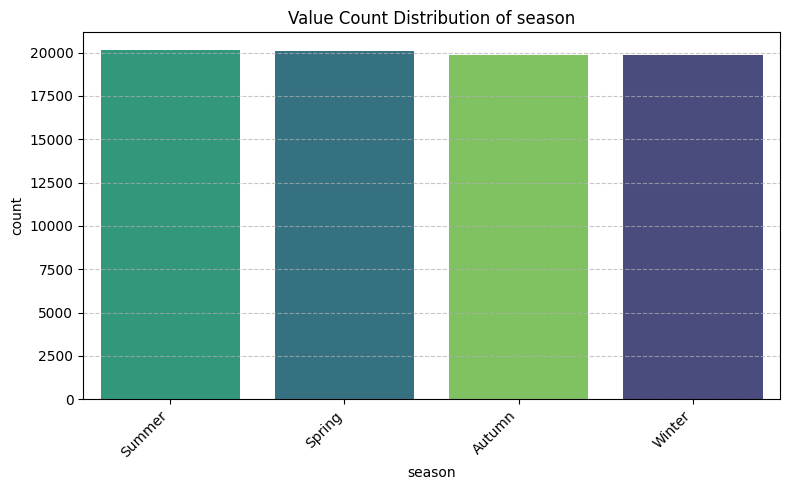

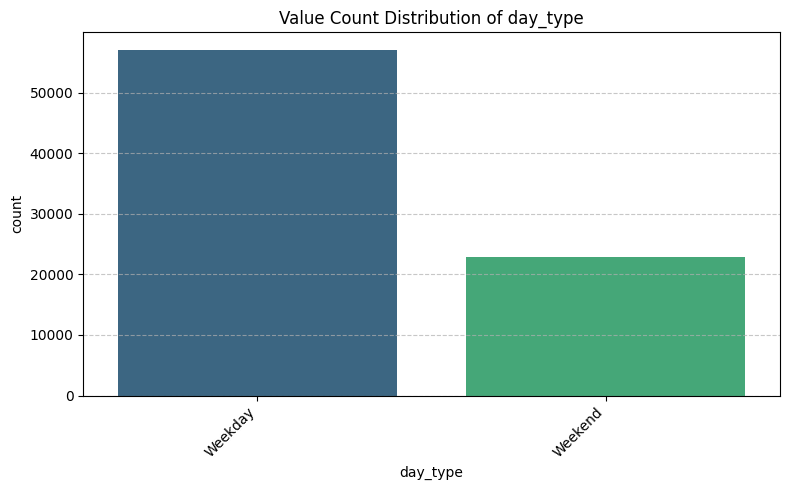

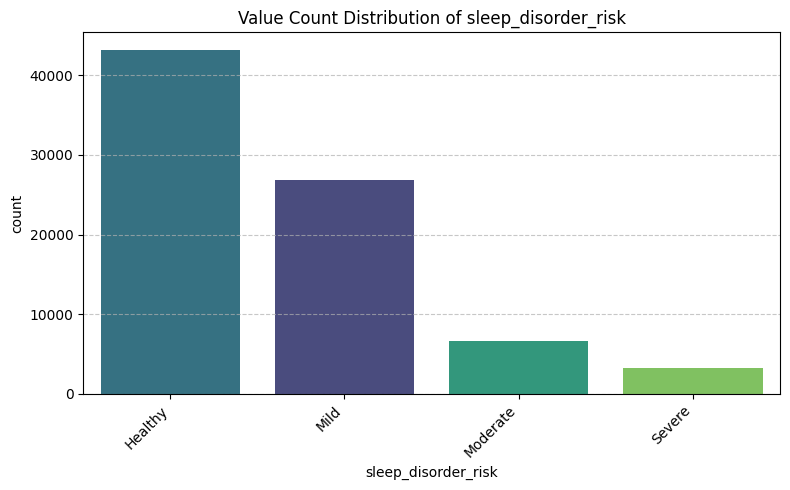

All plots have been generated and saved to a single MLflow run.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import os

# Get columns excluding 'person_id'
columns_to_plot = [col for col in train_df.columns if col != 'person_id']

# Main experiment setup
mlflow.set_experiment('Sleep_Disorder_Risk_Prediction')

# Ensure a local directory exists for temporary plot files
os.makedirs('plots', exist_ok=True)

# Start a single run to contain all plot artifacts
with mlflow.start_run(run_name='Feature_Distributions'):
    for column in columns_to_plot:
        fig = plt.figure(figsize=(8, 5))

        # Use countplot for categorical or low-cardinality numerical features
        if train_df[column].dtype == 'object' or train_df[column].nunique() < 20:
            sns.countplot(data=train_df, x=column, order=train_df[column].value_counts().index, palette='viridis', hue=column, legend=False)
            plt.title(f'Value Count Distribution of {column}')
            plt.xticks(rotation=45, ha='right')
        else:
            # Use histplot for high-cardinality numerical features
            sns.histplot(data=train_df, x=column, kde=True, bins=30, color='skyblue')
            plt.title(f'Distribution of {column}')

        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Define the local path
        plot_path = f"plots/distribution_{column}.png"
        # Save locally
        fig.savefig(plot_path)

        # Log the file as an artifact to the current active run
        mlflow.log_artifact(plot_path)

        # Display in notebook
        plt.show()
        plt.close(fig)

print("All plots have been generated and saved to a single MLflow run.")

## Unique Values in Each Feature / Column

In [ ]:
columns = train_df.columns.tolist()

num_columns = list()
cat_columns = list()

# not taking id and target columns into consideration
for col in columns[1:-1]:
  if (df[col].dtype == 'object' or len(df[col].unique()) <= 5):
    cat_columns.append(col)
  else:
    num_columns.append(col)

In [ ]:
print(num_columns)
print(cat_columns)

['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'room_temperature_celsius', 'weekend_sleep_diff_hrs']
['gender', 'occupation', 'country', 'exercise_day', 'chronotype', 'mental_health_condition', 'sleep_aid_used', 'shift_work', 'season', 'day_type']


In [ ]:
# unique values in categorical columns

for col in cat_columns:
  print(f"{col} : {train_df[col].unique()}")

gender : ['Other' 'Male' 'Female']
occupation : ['Software Engineer' 'Manager' 'Lawyer' 'Retired' 'Teacher' 'Doctor'
 'Student' 'Driver' 'Freelancer' 'Sales' 'Nurse' 'Homemaker']
country : ['South Korea' 'Brazil' 'Netherlands' 'India' 'UK' 'Japan' 'Germany'
 'Canada' 'Australia' 'USA' 'Italy' 'Mexico' 'Sweden' 'France' 'Spain']
exercise_day : [1 0]
chronotype : ['Evening' 'Neutral' 'Morning']
mental_health_condition : ['Anxiety' 'Healthy' 'Both' 'Depression']
sleep_aid_used : [1 0]
shift_work : [0 1]
season : ['Winter' 'Spring' 'Summer' 'Autumn']
day_type : ['Weekday' 'Weekend']


## Correlation Matrix

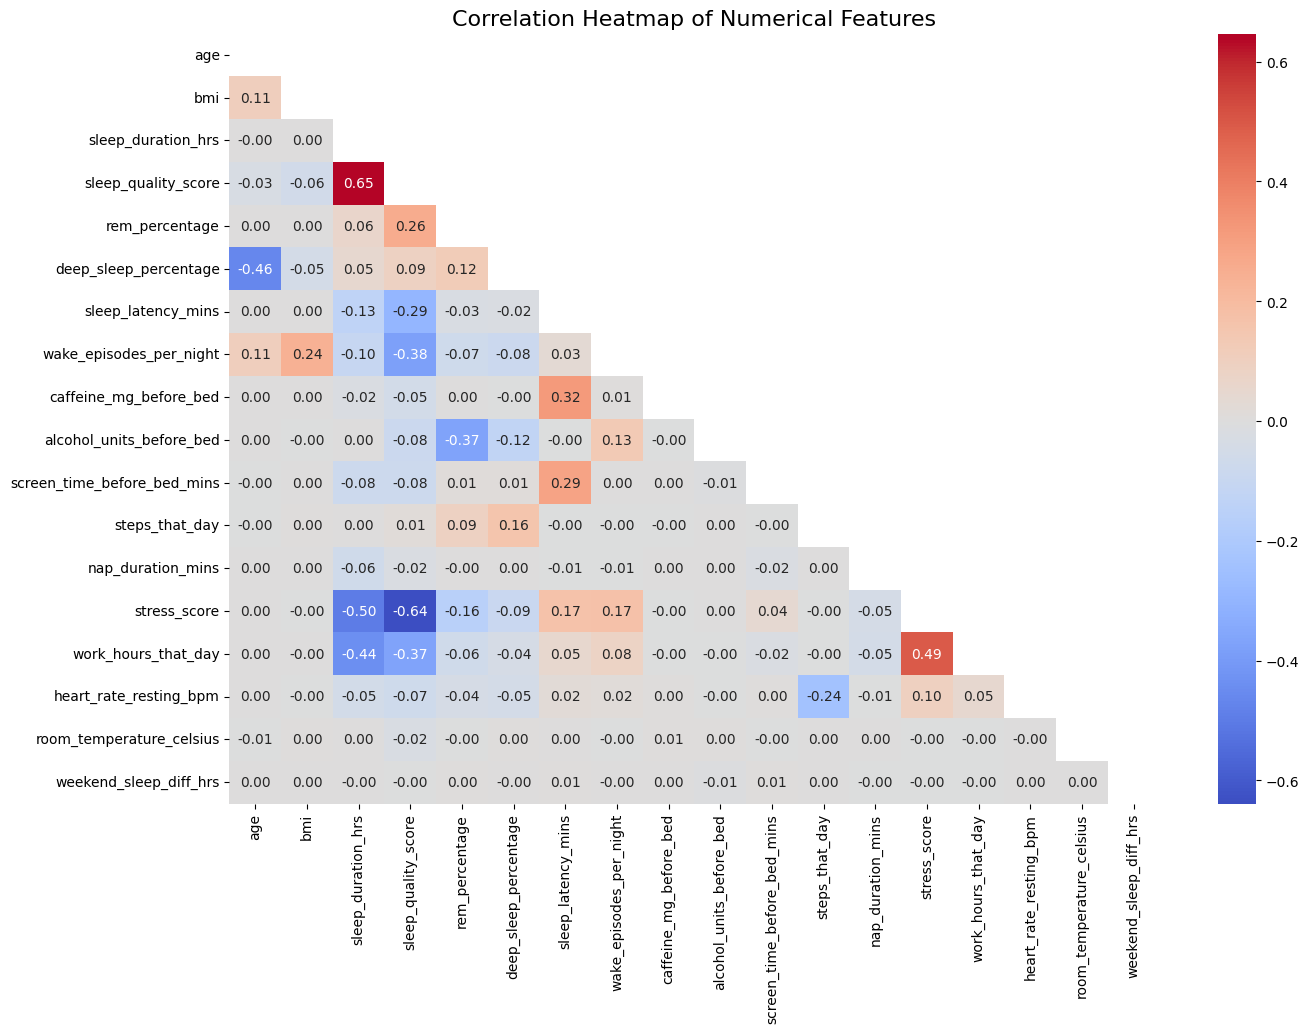

In [ ]:
plt.figure(figsize=(15, 10))
corr_mat = train_df[num_columns].corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Setting up the preprocessor

In [ ]:
X = train_df.drop(columns=['sleep_disorder_risk'])
y = train_df['sleep_disorder_risk']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.33)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# this will automatically drop the id column from the test dataset too
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns)
    ])

# Models

## K-NN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="KNN_Classifier"):
    knn_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
    ])

    mlflow.log_param("model_type", "KNeighborsClassifier")
    knn_pipeline.fit(X_train, y_train)
    y_pred_knn = knn_pipeline.predict(X_val)

    log_classification_report_metrics(y_val, y_pred_knn, prefix="val_")
    mlflow.log_metric("val_accuracy", knn_pipeline.score(X_val, y_val))

    mlflow.sklearn.log_model(sk_model=knn_pipeline, name="model")

print("K-NN Classifier (Validation Set) complete.")
print(classification_report(y_val, y_pred_knn))

2026/04/10 09:35:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


K-NN Classifier (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       0.77      0.95      0.85     14264
        Mild       0.62      0.57      0.59      8919
    Moderate       0.37      0.08      0.13      2177
      Severe       0.87      0.19      0.31      1040

    accuracy                           0.72     26400
   macro avg       0.66      0.45      0.47     26400
weighted avg       0.69      0.72      0.69     26400



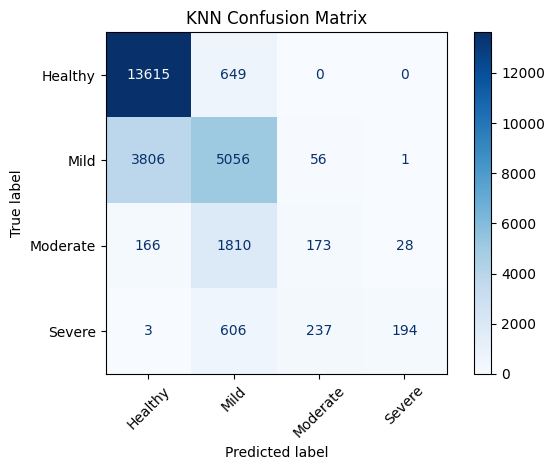

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define labels
labels = ["Healthy", "Mild", "Moderate", "Severe"]

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred_knn)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)

plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
!pip install imbalanced-learn --quiet

## SMOTE + KNN Classifier
Addressing class imbalance by oversampling the minority classes.

2026/04/10 09:37:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SMOTE + KNN (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       0.91      0.80      0.85     14264
        Mild       0.62      0.54      0.58      8919
    Moderate       0.27      0.55      0.37      2177
      Severe       0.35      0.60      0.44      1040

    accuracy                           0.68     26400
   macro avg       0.54      0.62      0.56     26400
weighted avg       0.74      0.68      0.70     26400



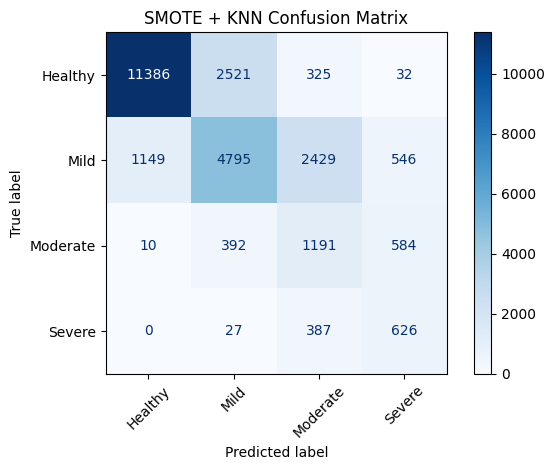

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="SMOTE_KNN"):
    # We use ImbPipeline because standard sklearn Pipeline doesn't support SMOTE correctly during fit
    smote_knn_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=67)),
        ('classifier', KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
    ])

    mlflow.log_param("model_type", "SMOTE_KNeighborsClassifier")
    mlflow.log_param("n_neighbors", 15)

    smote_knn_pipeline.fit(X_train, y_train)
    y_pred_smote_knn = smote_knn_pipeline.predict(X_val)

    log_classification_report_metrics(y_val, y_pred_smote_knn, prefix="val_")
    mlflow.log_metric("val_accuracy", smote_knn_pipeline.score(X_val, y_val))

    mlflow.sklearn.log_model(sk_model=smote_knn_pipeline, name="model")

print("SMOTE + KNN (Validation Set) complete.")
print(classification_report(y_val, y_pred_smote_knn))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_smote_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("SMOTE + KNN Confusion Matrix")
plt.tight_layout()
plt.show()

- KNN Classifier performs badly because of the high class imbalance
- KNN + SMOTE is comparatively better as the class imbalance gets taken care of by SMOTE

## Logistic Regression

2026/04/10 09:37:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       0.90      0.91      0.91     14264
        Mild       0.76      0.79      0.77      8919
    Moderate       0.58      0.47      0.52      2177
      Severe       0.75      0.67      0.71      1040

    accuracy                           0.82     26400
   macro avg       0.75      0.71      0.73     26400
weighted avg       0.82      0.82      0.82     26400



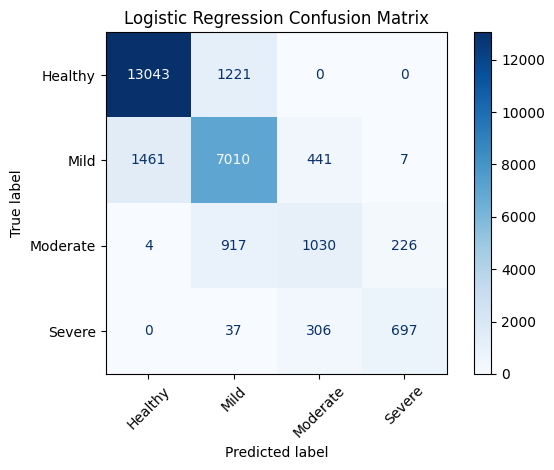

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="Logistic_Regression"):
    log_reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=67, n_jobs=-1, max_iter=1000))
    ])

    mlflow.log_param("model_type", "LogisticRegression")
    log_reg_pipeline.fit(X_train, y_train)
    y_pred_log_reg = log_reg_pipeline.predict(X_val)

    log_classification_report_metrics(y_val, y_pred_log_reg, prefix="val_")
    mlflow.log_metric("val_accuracy", log_reg_pipeline.score(X_val, y_val))

    mlflow.sklearn.log_model(sk_model=log_reg_pipeline, name="model")

print("Logistic Regression (Validation Set) complete.")
print(classification_report(y_val, y_pred_log_reg))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_log_reg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## PCA + Logistic Regression

2026/04/10 09:41:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression with PCA (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       0.89      0.91      0.90     14264
        Mild       0.74      0.77      0.75      8919
    Moderate       0.52      0.40      0.45      2177
      Severe       0.70      0.58      0.63      1040

    accuracy                           0.81     26400
   macro avg       0.71      0.66      0.68     26400
weighted avg       0.80      0.81      0.80     26400



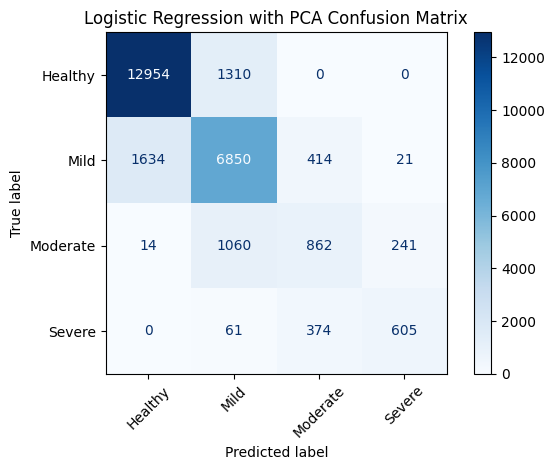

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline # Make sure Pipeline is imported
import matplotlib.pyplot as plt

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="Logistic_Regression_PCA"):
    # Define the PCA + Logistic Regression pipeline
    log_reg_pca_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)), # Retain 95% of variance
        ('classifier', LogisticRegression(random_state=67, n_jobs=-1, max_iter=1000))
    ])

    # Log parameters
    mlflow.log_param("model_type", "LogisticRegression_with_PCA")
    mlflow.log_param("pca_n_components", 0.95)

    # Fit the model
    log_reg_pca_pipeline.fit(X_train, y_train)
    y_pred_log_reg_pca = log_reg_pca_pipeline.predict(X_val)

    # Log metrics
    log_classification_report_metrics(y_val, y_pred_log_reg_pca, prefix="val_")
    mlflow.log_metric("val_accuracy", log_reg_pca_pipeline.score(X_val, y_val))

    # Log the model
    mlflow.sklearn.log_model(sk_model=log_reg_pca_pipeline, name="model")

print("Logistic Regression with PCA (Validation Set) complete.")
print(classification_report(y_val, y_pred_log_reg_pca))

# Confusion Matrix
cm_log_reg_pca = confusion_matrix(y_val, y_pred_log_reg_pca)
disp_log_reg_pca = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_pca, display_labels=labels)
disp_log_reg_pca.plot(cmap='Blues', xticks_rotation=45)
plt.title("Logistic Regression with PCA Confusion Matrix")
plt.tight_layout()
plt.show()

## Random Forest Classifier

2026/04/10 09:39:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96     14264
        Mild       0.83      0.92      0.87      8919
    Moderate       0.68      0.42      0.52      2177
      Severe       0.85      0.66      0.75      1040

    accuracy                           0.89     26400
   macro avg       0.83      0.74      0.78     26400
weighted avg       0.89      0.89      0.89     26400



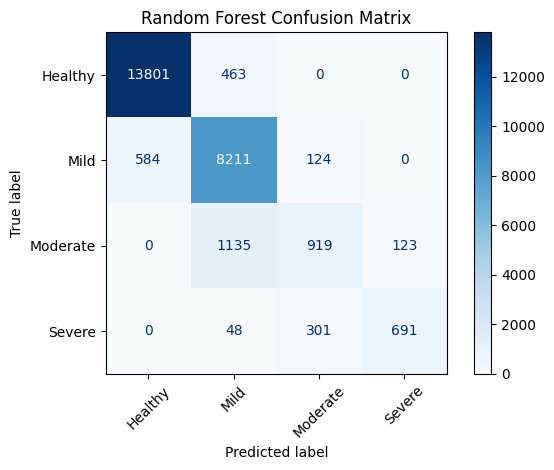

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="Random_Forest"):
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=67,
                                              n_estimators = 300,
                                              class_weight = 'balanced',
                                              n_jobs=-1
                                              ))
    ])

    mlflow.log_param("model_type", "RandomForestClassifier")
    rf_pipeline.fit(X_train, y_train)
    y_pred_rf = rf_pipeline.predict(X_val)

    log_classification_report_metrics(y_val, y_pred_rf, prefix="val_")
    mlflow.log_metric("val_accuracy", rf_pipeline.score(X_val, y_val))

    mlflow.sklearn.log_model(sk_model=rf_pipeline, name="model")

print("Random Forest (Validation Set) complete.")
print(classification_report(y_val, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LightGBM Classifier

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2467
[LightGBM] [Info] Number of data points in the train set: 53600, number of used features: 67
[LightGBM] [Info] Start training from score -1.328061
[LightGBM] [Info] Start training from score -1.399635
[LightGBM] [Info] Start training from score -1.407568
[LightGBM] [Info] Start training from score -1.412291


2026/04/10 09:39:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM (Validation Set) complete.
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99     14264
        Mild       0.96      0.90      0.93      8919
    Moderate       0.66      0.82      0.73      2177
      Severe       0.81      0.86      0.84      1040

    accuracy                           0.94     26400
   macro avg       0.86      0.89      0.87     26400
weighted avg       0.95      0.94      0.94     26400



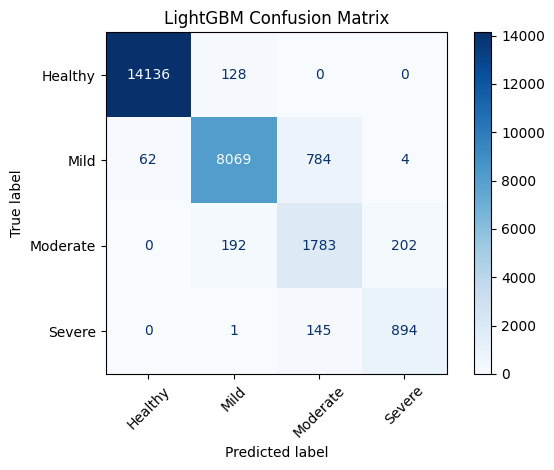

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlflow.set_experiment("Sleep_Disorder_Risk_Prediction")

with mlflow.start_run(run_name="LightGBM_Initial"):
    lgbm_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(
            random_state=67,
            n_jobs=-1,
            class_weight={'Healthy': 1, 'Mild': 1.5, 'Moderate': 6, 'Severe': 12},
            objective='multiclass'
            ))
    ])

    mlflow.log_param("model_type", "LGBMClassifier")
    lgbm_pipeline.fit(X_train, y_train)
    y_pred_lgbm = lgbm_pipeline.predict(X_val)

    log_classification_report_metrics(y_val, y_pred_lgbm, prefix="val_")
    mlflow.log_metric("val_accuracy", lgbm_pipeline.score(X_val, y_val))

    mlflow.sklearn.log_model(sk_model=lgbm_pipeline, name="model")

print("LightGBM (Validation Set) complete.")
print(classification_report(y_val, y_pred_lgbm))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_lgbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.show()

# Test Scoring

## LightGBM

In [ ]:
with mlflow.start_run(run_name="LightGBM_Test_Set_Evaluation"):
    # Retrain the LightGBM model on the full training data (X, y) before final test
    lgbm_pipeline.fit(X, y)

    # Predict on the unseen test set using the best performing model (LightGBM)
    y_pred_lgbm_test = lgbm_pipeline.predict(X_test)

    # Log metrics for the test set
    log_classification_report_metrics(y_test, y_pred_lgbm_test, prefix="test_")
    mlflow.log_metric("test_accuracy", lgbm_pipeline.score(X_test, y_test))

    # Log the final model trained on all data
    mlflow.sklearn.log_model(sk_model=lgbm_pipeline, name="final_lgbm_model")

print("Classification Report for LightGBM on Test Set:")
print(classification_report(y_test, y_pred_lgbm_test))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2479
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 67
[LightGBM] [Info] Start training from score -1.324105
[LightGBM] [Info] Start training from score -1.393203
[LightGBM] [Info] Start training from score -1.406418
[LightGBM] [Info] Start training from score -1.424365


2026/04/10 09:40:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Classification Report for LightGBM on Test Set:
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99     10937
        Mild       0.96      0.91      0.93      6590
    Moderate       0.68      0.82      0.75      1665
      Severe       0.82      0.87      0.85       808

    accuracy                           0.95     20000
   macro avg       0.86      0.90      0.88     20000
weighted avg       0.95      0.95      0.95     20000



### Model Performance Comparison (Macro Average)

| Model | Macro Precision | Macro Recall | Macro F1-Score |
| :--- | :---: | :---: | :---: |
| **K-NN Classifier** | 0.66 | 0.45 | 0.48 |
| **SMOTE + KNN** | 0.54 | 0.62 | 0.56 |
| **Logistic Regression** | 0.75 | 0.71 | 0.73 |
| **Random Forest** | 0.84 | 0.76 | 0.79 |
| **LightGBM (Validation)** | 0.86 | 0.89 | 0.87 |
| **LightGBM (Test Set)** | 0.86 | 0.90 | 0.88 |

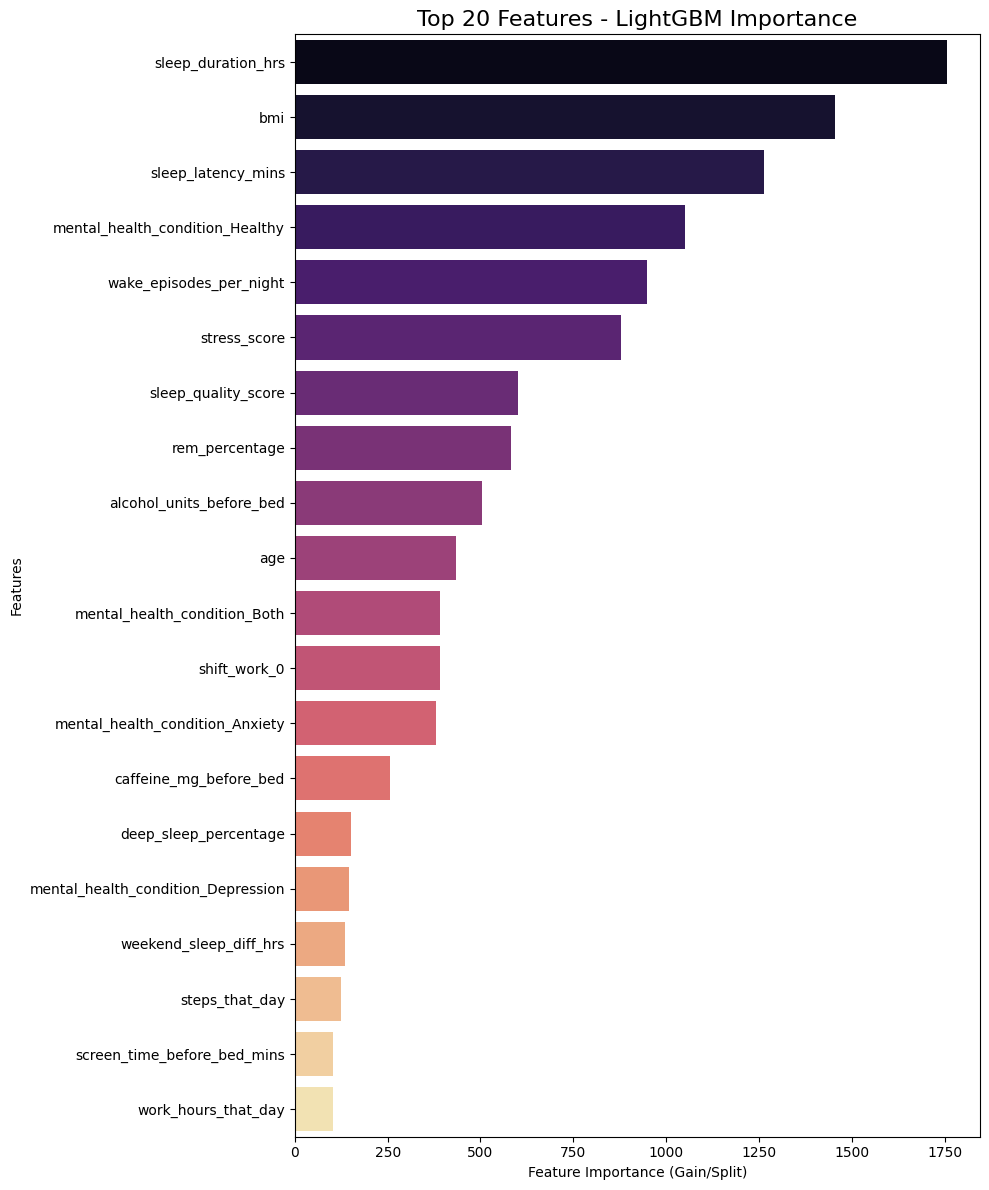

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the trained model from the pipeline
lgbm_model = lgbm_pipeline.named_steps['classifier']

# Get feature names from the preprocessor
cat_feature_names = lgbm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_columns)
feature_names = num_columns + list(cat_feature_names)

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 12))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Top 20 Features - LightGBM Importance', fontsize=16)
plt.xlabel('Feature Importance (Gain/Split)')
plt.ylabel('Features')
plt.tight_layout()

# Save locally before showing
plt.savefig("feature_importance.png")
plt.show()

# Log the importance plot to MLflow in the last active run
with mlflow.start_run(run_name="Feature_Importance_Analysis"):
    mlflow.log_artifact("feature_importance.png")
    mlflow.log_dict(importance_df.to_dict(), "feature_importance_data.json")

In [ ]:
import shutil
from google.colab import files

# Zip the mlruns folder
shutil.make_archive('mlruns', 'zip', './mlruns')

# Download the zipped folder
files.download('mlruns.zip')

print('MLflow runs have been zipped and the download has started.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MLflow runs have been zipped and the download has started.


## Conclusion

In this notebook, we performed a comprehensive analysis to predict **Sleep Disorder Risk** using a dataset of 100,000 entries.

### Key Findings:
1. **Model Performance**: Among the various models tested (K-NN, Logistic Regression, Random Forest, and LightGBM), **LightGBM** emerged as the superior model. By implementing custom class weights to handle the inherent class imbalance, it achieved a **Macro F1-Score of 0.88** and an overall **Test Accuracy of 95%**.
2. **Feature Importance**: Analysis of the LightGBM model revealed that **Sleep Duration**, **BMI**, and **Sleep Latency** are the strongest predictors of sleep disorder risk. Mental health status (Healthy vs. Anxiety/Depression) also played a significant role.
3. **MLflow Integration**: All experiments, including hyperparameter settings, classification metrics, and visual artifacts like feature importance and distribution plots, were systematically logged using MLflow for reproducibility.

### Future Work:
- Further hyperparameter tuning of the LightGBM model using tools like Optuna.
- Exploring more advanced oversampling techniques beyond standard SMOTE.
- Engineering new features based on the interactions between 'Physical Activity' and 'Sleep Quality'.